# Feature maps and Grad-CAM

**Learning objective:** Inspect internal activations and compute a class-specific Grad-CAM heatmap for a trained CNN.

This notebook is part of the TensorFlow/Keras learning track. It is designed to be read top-to-bottom: intuition → shapes → mathematics → TensorFlow implementation → observed result → interpretation.

> GitHub renders the committed executed output as a static learning artifact. Clone the repository and rerun it in Jupyter/VS Code for live experimentation.


In [1]:
import os, warnings, random
from pathlib import Path
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.keras.utils.set_random_seed(SEED)

print("TensorFlow:", tf.__version__)
print("Keras:", tf.keras.__version__ if hasattr(tf.keras, "__version__") else "bundled with TensorFlow")
print("Execution device(s):", [d.device_type for d in tf.config.list_logical_devices()])


2026-09-21 07:16:22.473205: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1789974982.489103    4230 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1789974982.493496    4230 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


TensorFlow: 2.18.1
Keras: 3.15.1
Execution device(s): ['CPU']


2026-09-21 07:16:24.215129: E external/local_xla/xla/stream_executor/cuda/cuda_driver.cc:152] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


In [2]:
(x,y),(xt,yt)=tf.keras.datasets.fashion_mnist.load_data(); x=x[:4000,...,None].astype("float32")/255; y=y[:4000]; xt=xt[:200,...,None].astype("float32")/255
inputs=tf.keras.Input((28,28,1)); z=tf.keras.layers.Conv2D(16,3,padding="same",activation="relu",name="conv1")(inputs); z=tf.keras.layers.MaxPooling2D()(z); z=tf.keras.layers.Conv2D(32,3,padding="same",activation="relu",name="conv2")(z); z=tf.keras.layers.GlobalAveragePooling2D()(z); outputs=tf.keras.layers.Dense(10,activation="softmax")(z)
model=tf.keras.Model(inputs,outputs); model.compile(optimizer="adam",loss="sparse_categorical_crossentropy",metrics=["accuracy"]); model.fit(x,y,epochs=1,batch_size=64,verbose=0)
grad_model=tf.keras.Model(model.inputs,[model.get_layer("conv2").output,model.output])
sample=tf.convert_to_tensor(xt[:1]);
with tf.GradientTape() as tape:
    conv,preds=grad_model(sample); cls=tf.argmax(preds[0]); score=preds[:,cls]
grads=tape.gradient(score,conv); weights=tf.reduce_mean(grads,axis=(0,1,2)); heat=tf.reduce_sum(conv[0]*weights,axis=-1); heat=tf.maximum(heat,0); heat=heat/(tf.reduce_max(heat)+1e-8)
print("predicted class:",int(cls),"confidence:",round(float(tf.reduce_max(preds)),4),"heatmap shape:",heat.shape)


predicted class: 8 confidence: 0.1111 heatmap shape: (14, 14)


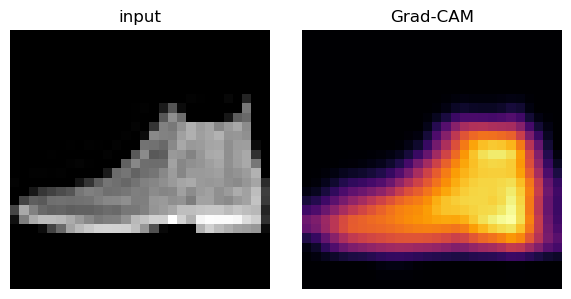

In [3]:
fig,axes=plt.subplots(1,2,figsize=(6,3)); axes[0].imshow(xt[0,:,:,0],cmap="gray"); axes[0].set_title("input"); axes[1].imshow(tf.image.resize(heat[...,None],(28,28)).numpy()[:,:,0],cmap="inferno"); axes[1].set_title("Grad-CAM"); [a.axis("off") for a in axes]; plt.tight_layout(); plt.show()


Grad-CAM is an explanatory diagnostic, not proof of causal reasoning. Use it to inspect where class-sensitive gradients concentrate and combine it with quantitative error analysis.
